In [109]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.integrate import simps
from scipy.stats import norm

In [259]:
# Specify Parameters
# mu = 0.0974/252 #SP500 YTD Return to Daily
mu = 0.1298/252
r = 0
volvol = 0.1/np.sqrt(252)
reversion_rate = k = 20/252
S0 = 100
# V0 = (0.11/np.sqrt(5))**2 #SP500 Weekly Avg Vol to Daily
V0 = (0.12/np.sqrt(21))**2
long_run_var = (0.12/np.sqrt(21))**2 #SP500 Monthly Avg Vol to Daily
rho = 0.5

T = 252 #days
dt = 1/100 #days


strike = 120
risk_aversion_factor = 0.01
distortion_factor = float()
N = 100 #Nums of Simulation 

In [220]:
 (0.12/np.sqrt(21))**2

0.0006857142857142858

In [221]:
def cor_bw(T, rho):
  random_matrix = np.random.normal(size=(2, int(T/dt) + 1))
  bw_1 = random_matrix[0] * np.sqrt(dt)
  bw_2 = (random_matrix[0] * rho + np.sqrt((1 - rho**2)) * random_matrix[1]) * np.sqrt(dt)
  return bw_1, bw_2

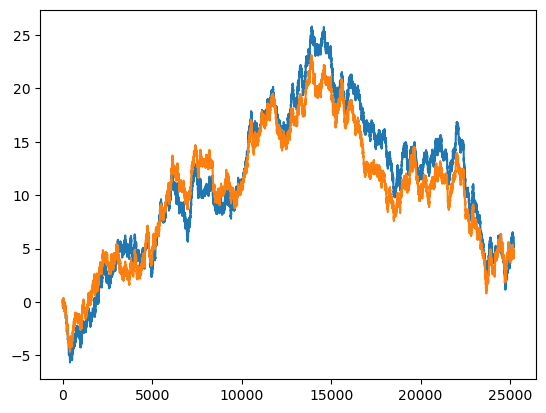

In [222]:
# Sample BMs
bw_1, bw_2 = cor_bw(T, rho)
plt.plot(range(int(T/dt) + 1), bw_1.cumsum())
plt.plot(range(int(T/dt) + 1), bw_2.cumsum())

In [223]:
dt

0.01

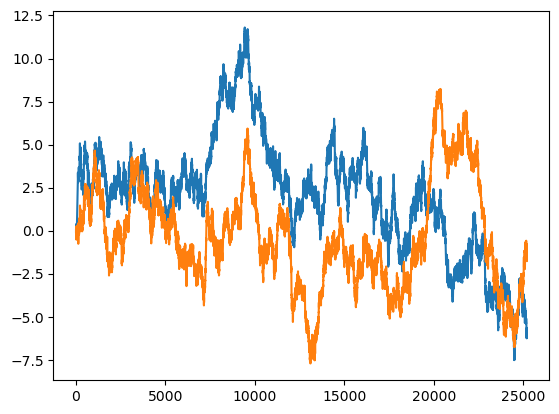

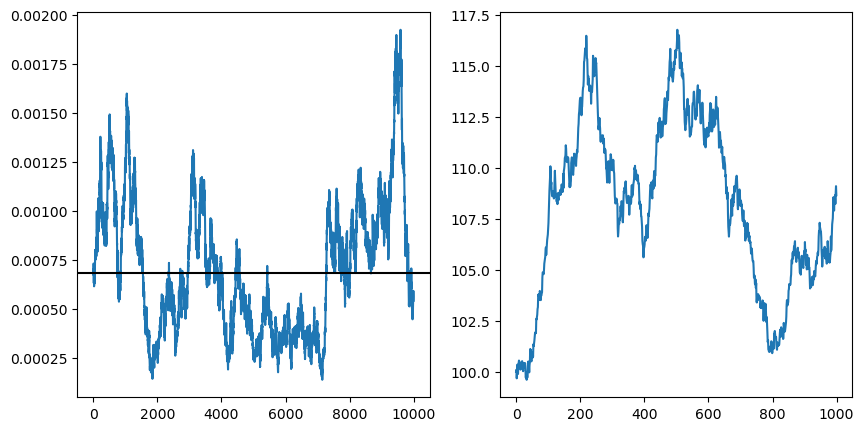

In [264]:
# Sample BMs
bw_1, bw_2 = cor_bw(T, rho)
plt.plot(range(int(T/dt) + 1), bw_1.cumsum())
plt.plot(range(int(T/dt) + 1), bw_2.cumsum())

def path_adjusted_V(reversion_rate, long_run_var, volvol, bw_1, bw_2, V0, T, mu):
    v = np.zeros(int(T/dt) + 1) 
    v[0] = V0
    for i in range(int(T/dt)):
        dv= reversion_rate * (long_run_var - (v[i]))*dt + \
                rho * volvol * np.sqrt((v[i])) * mu / np.sqrt((v[i])) * dt + \
                volvol * np.sqrt((v[i])) * (rho * bw_1[i] + np.sqrt(1 - rho**2) * bw_2[i])
        v[i + 1] = abs(v[i] + dv)
    return v

def path_V(reversion_rate, long_run_var, volvol, bw_1, bw_2, V0, T):
    v = np.zeros(int(T/dt) + 1) 
    v[0] = V0
    for i in range(int(T/dt)):
        dv = reversion_rate * (long_run_var - (v[i]))*dt + \
                volvol * np.sqrt((v[i])) * (rho * bw_1[i] + np.sqrt(1 - rho**2) * bw_2[i])
        v[i + 1] = np.abs(v[i] + dv)
    return v

def path_S(mu, v, bw_1, S0, T):
    s = np.zeros(int(T/dt) + 1)
    s[0] = S0
    for i in range(int(T/dt)):
#         ds = s[i] * mu * dt + np.sqrt((v[i])) * s[i] * bw_1[i]
#         s[i + 1] = s[i] + ds
        s[i + 1] = s[i]*(np.exp((mu- 0.5*v[i])*dt+ np.sqrt(v[i]) *bw_1[i]))
    return s

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sample_V = path_V(reversion_rate, long_run_var, volvol, bw_1, bw_2, V0, T)
plt.plot(list(range(int(T/dt) + 1)[:10000]), (sample_V[:10000]))
plt.axhline((long_run_var), color='black', label=r'$\sqrt{\theta}$')

plt.subplot(1, 2, 2)
sample_S = path_S(mu, sample_V, bw_1, S0, T)
plt.plot(list(range(int(T/dt) + 1))[:1000],sample_S[:1000])

In [265]:
def Expected_f(N, rho, a, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike):
    f_g_array = []
    f_0_array = []
    for i in range(N):
        bw_1, bw_2 = cor_bw(T, rho)
        v = path_adjusted_V(reversion_rate, long_run_var, volvol, bw_1, bw_2, V0, T, mu)
        s = path_S(mu, v, bw_1, S0, T)
        ST = s[-1]
        g_payoff = max(ST - strike, 0)
        
        lambda_array = mu / np.sqrt(v)
        
        integral = simps(lambda_array**2, dx=0.01)
        f_g_array.append(np.exp((1-rho**2) * (a * g_payoff - 1/2 * integral)))
        f_0_array.append(np.exp((1-rho**2) * (-1/2 * integral)))
    return np.mean(f_g_array), np.mean(f_0_array), v, bw_1

#f_g_mean, f_0_mean, f_g_std, f_0_std = Expected_f()

In [266]:
def UtilityPricer(N, rho, a, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike):
    f_g_mean, f_0_mean, v, bw_1 = Expected_f(N, rho, a, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike)
    delta = 1 - rho**2
    F_g = f_g_mean ** (1 / delta)
    F_0 = f_0_mean ** (1 / delta)
    price = 1/a * np.log((F_g / F_0))
    return price, F_g, F_0, v, bw_1

In [267]:
price, F_g, F_0, v, bw_1 = UtilityPricer(N, rho, risk_aversion_factor, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike)

27.982864003577685

In [269]:
def bsPricer(S0, strike, sigma, r, T):
    d1 = (np.log(S0/strike) + (r + sigma ** 2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * norm.cdf(d1) - strike * np.exp(-r * T) * norm.cdf(d2)
    return price

In [270]:
bsPricer(S0, strike, np.sqrt(V0), 0, T)

9.795870023533645

In [271]:
def hedging_ratio(outer_N, N, rho, a, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike):
    h = 1.49e-10
    price_array = np.zeros(outer_N)
    price_plus = 0
    
    for i in range(outer_N):
        f_g = 0
        f_g_plus = 0

        f_0 = 0
        f_0_plus = 0
 
        for j in range(N):
            bw_1, bw_2 = cor_bw(T, rho)

            v = path_adjusted_V(reversion_rate, long_run_var, volvol, bw_1, bw_2, V0, T, mu)
            v_plus = v + h



            s = path_S(mu, v, bw_1, S0, T)
            s_plus = path_S(mu, v_plus, bw_1, S0, T)


            ST = s[-1]
            ST_plus = s_plus[-1]


            g_payoff = max(ST - strike, 0)
            g_plus_payoff = max(ST_plus - strike, 0)
            
            lambda_array = mu / np.sqrt(v)
            lambda_array_plus = mu / np.sqrt(v_plus)
            
            integral = simps(lambda_array**2, dx=1)
            integral_plus = simps(lambda_array_plus ** 2, dx = 1)


            f_g = f_g + np.exp((1-rho**2) * (a * g_payoff - 1/2 * integral))
            f_0 = f_0 + np.exp((1-rho**2) * (-1/2 * integral))

            f_g_plus = f_g_plus + np.exp((1-rho**2) * (a * g_plus_payoff - 1/2 * integral_plus))
            f_0_plus = f_0_plus + np.exp((1-rho**2) * (-1/2 * integral_plus))
        
        
        
        #Simulation finished
        f_g_mean = np.mean(f_g)
        f_0_mean = np.mean(f_0)

        f_g_plus_mean = np.mean(f_g_plus)
        f_0_plus_mean = np.mean(f_0_plus)


        delta = 1 - rho**2
        F_g = f_g_mean ** (1 / delta)
        F_0 = f_0_mean ** (1 / delta)
        price_array[i] = 1/a * np.log((F_g / F_0))

        F_g_plus = f_g_plus_mean ** (1 / delta)
        F_0_plus = f_0_plus_mean ** (1 / delta)
        price_plus = price_plus + 1/a * np.log((F_g_plus / F_0_plus))
        
        
    
    price_mean = np.mean(price_array)
    std_price = np.std(price_array)
    
    
    price_plus_mean = price_plus / outer_N
    DPDY =  (price_plus_mean - price_mean)/(h)
    ratio = rho * volvol * np.sqrt(v) / v * DPDY 
         
    return price_mean, std_price, ratio, DPDY, price_plus_mean

In [ ]:
price, std_price, ratio, DPDY, price_plus = hedging_ratio(1000, 1000, rho, risk_aversion_factor, T, reversion_rate, long_run_var, V0, volvol, mu, S0, strike)

In [ ]:
price

In [ ]:
std_price

In [ ]:
std_price

In [ ]:
ratio

In [ ]:
DPDY

In [ ]:
price_plus 

In [ ]:
ratio 

In [ ]:
plt.plot(ratio)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


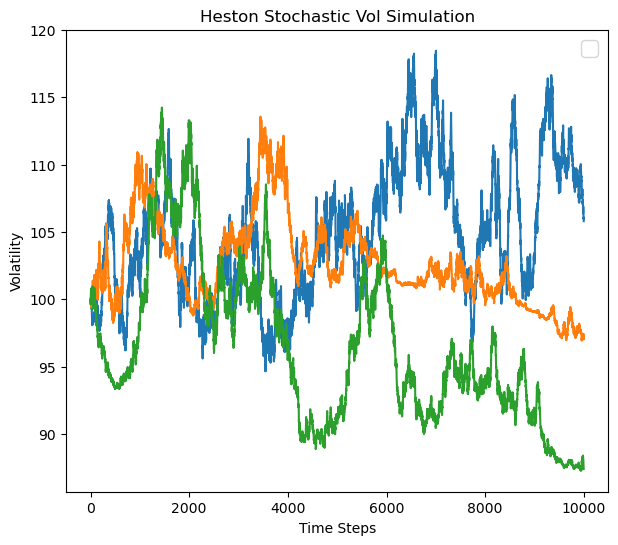

In [98]:
def generate_heston_paths(S, T, r, kappa, theta, v_0, rho, xi, 
                          steps, Npaths, return_vol=False):
    dt = T/steps
    size = (Npaths, steps)
    prices = np.zeros(size)
    sigs = np.zeros(size)
    S_t = S
    v_t = v_0
    for t in range(steps):
        WT = np.random.multivariate_normal(np.array([0,0]), 
                                           cov = np.array([[1,rho],
                                                          [rho,1]]), 
                                           size=Npaths) * np.sqrt(dt) 
        
        S_t = S_t*(np.exp( (r- 0.5*v_t)*dt+ np.sqrt(v_t) *WT[:,0] ) ) 
        v_t = np.abs(v_t + kappa*(theta-v_t)*dt + xi*np.sqrt(v_t)*WT[:,1])
        prices[:, t] = S_t
        sigs[:, t] = v_t
    
    if return_vol:
        return prices, sigs
    
    return prices

kappa =3
theta = 0.04
v_0 =  0.04
xi = 0.6
r = 0.05
S = 100
paths =3
steps = 10000
T = 1
rho = -0.8
T = 1

prices_pos, vol_pos = generate_heston_paths(S, T, r, kappa, theta,
                                    v_0, rho=0.9, xi=xi, steps=steps, Npaths=paths,
                                    return_vol=True)

plt.figure(figsize=(7,6))
plt.plot(prices_pos.T)
plt.title('Heston Stochastic Vol Simulation')
plt.xlabel('Time Steps')
plt.ylabel('Volatility')
plt.legend(fontsize=15)
plt.show()

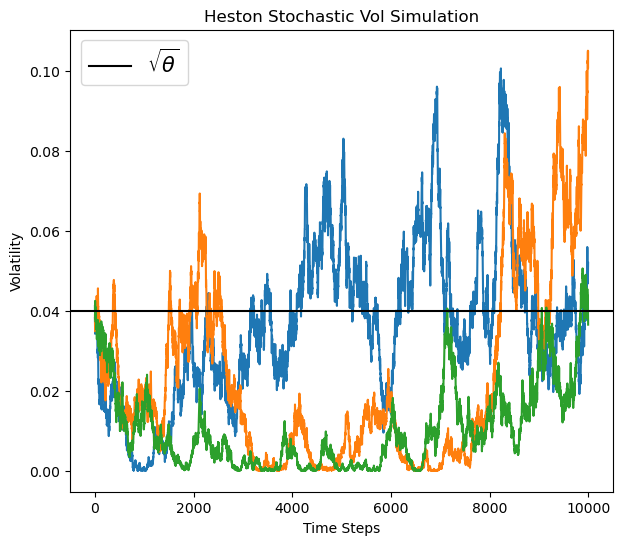

In [95]:

plt.figure(figsize=(7,6))
plt.plot((vol_pos.T))
plt.axhline((theta), color='black', label=r'$\sqrt{\theta}$')
plt.title('Heston Stochastic Vol Simulation')
plt.xlabel('Time Steps')
plt.ylabel('Volatility')
plt.legend(fontsize=15)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=be910d73-115a-4bd8-9e85-24a28d5acd0a' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>